# RNN Decoder Training - Semua Variasi

Notebook ini melatih 6 variasi SimpleRNN decoder untuk task image captioning di Flickr8k. Setiap model disimpan terpisah supaya bisa dibandingkan di notebook eksperimen.

In [1]:
import os, json, sys, time, pickle
import numpy as np
from pathlib import Path


def _find_root(marker="requirements.txt"):
    p = Path(os.getcwd())
    while p != p.parent:
        if (p / marker).exists():
            return p
        p = p.parent
    raise RuntimeError("Repo root tidak ketemu, pastikan requirements.txt ada di root.")


REPO_ROOT = _find_root()
os.chdir(REPO_ROOT)
print("Working dir:", REPO_ROOT)

Working dir: c:\Users\Farrel's Laptop\Desktop\mlml\CNN-RNN-digaspolndangakndangak


In [2]:
sys.path.insert(0, str(REPO_ROOT / "src"))

import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

from shared.caption_utils import clean_caption, encode_caption, load_vocabulary
from rnn.train_keras import build_rnn_decoder, train as train_model

tf.random.set_seed(42)
np.random.seed(42)

## Config

In [3]:
FEATURES_DIR = "features"
MODELS_DIR   = "models/rnn"
HISTORY_DIR  = "models/rnn/history"

FEATURES_NPY = os.path.join(FEATURES_DIR, "flickr8k_features.npy")
VOCAB_JSON   = os.path.join(FEATURES_DIR, "vocab.json")
IDX_JSON     = os.path.join(FEATURES_DIR, "flickr8k_idx.json")
SPLITS_JSON  = os.path.join(FEATURES_DIR, "splits.json")
CAPTIONS_TXT = "data/flickr8k/captions.txt"

FEATURE_DIM  = 2048   # output InceptionV3 avg pool
EMBED_DIM    = 256
MAX_SEQ_LEN  = 34
BATCH_SIZE   = 64
MAX_EPOCHS   = 20

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(HISTORY_DIR, exist_ok=True)

## Load data

In [4]:
features = np.load(FEATURES_NPY)
vocab    = load_vocabulary(VOCAB_JSON)
VOCAB_SIZE = len(vocab)

with open(IDX_JSON)    as f: idx_map = json.load(f)
with open(SPLITS_JSON) as f: splits  = json.load(f)

caption_map = {}
with open(CAPTIONS_TXT) as f:
    next(f)
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split(",", 1)
        if len(parts) != 2:
            continue
        img_file, caption = parts
        img_id = os.path.splitext(img_file)[0]
        caption_map.setdefault(img_id, []).append(caption)

train_ids = splits["train"]
val_ids   = splits["val"]

print(f"Vocab size: {VOCAB_SIZE}, Features: {features.shape}")
print(f"Train images: {len(train_ids)}, Val images: {len(val_ids)}")

Vocab size: 7684, Features: (8091, 2048)
Train images: 6000, Val images: 1000


## Dataset builder

Logikanya sama seperti di notebook 06, ditulis ulang di sini supaya notebook ini bisa jalan secara mandiri tanpa harus import dari notebook lain.

In [5]:
def build_dataset(image_ids, shuffle=True, batch_size=BATCH_SIZE):
    pad_idx = vocab["<pad>"]
    feat_list, cap_in_list, target_list = [], [], []

    for img_id in image_ids:
        feat_idx = idx_map.get(img_id)
        if feat_idx is None:
            continue
        feat = features[feat_idx]
        for cap in caption_map.get(img_id, []):
            cleaned = clean_caption(cap)
            encoded = encode_caption(cleaned, vocab, MAX_SEQ_LEN)
            target  = np.append(encoded[1:], [pad_idx, pad_idx])
            feat_list.append(feat)
            cap_in_list.append(encoded)
            target_list.append(target)

    ds = tf.data.Dataset.from_tensor_slices((
        (np.array(feat_list,   dtype=np.float32),
         np.array(cap_in_list, dtype=np.int32)),
        np.array(target_list,  dtype=np.int32),
    ))
    if shuffle:
        ds = ds.shuffle(len(feat_list), reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


train_ds = build_dataset(train_ids, shuffle=True)
val_ds   = build_dataset(val_ids,   shuffle=False)

## Variasi training

Total 6 variasi, kombinasi dari jumlah layer (1, 2, 3) dan ukuran hidden state (128, 512):

| Nama | Layer | Units |
|---|---|---|
| rnn-1layer-128 | 1 | 128 |
| rnn-2layer-128 | 2 | 128 |
| rnn-3layer-128 | 3 | 128 |
| rnn-1layer-512 | 1 | 512 |
| rnn-2layer-512 | 2 | 512 |
| rnn-3layer-512 | 3 | 512 |

In [6]:
VARIATIONS = [
    {"name": "rnn-1layer-128", "num_rnn_layers": 1, "rnn_units": 128},
    {"name": "rnn-2layer-128", "num_rnn_layers": 2, "rnn_units": 128},
    {"name": "rnn-3layer-128", "num_rnn_layers": 3, "rnn_units": 128},
    {"name": "rnn-1layer-512", "num_rnn_layers": 1, "rnn_units": 512},
    {"name": "rnn-2layer-512", "num_rnn_layers": 2, "rnn_units": 512},
    {"name": "rnn-3layer-512", "num_rnn_layers": 3, "rnn_units": 512},
]

In [7]:
all_histories = {}

for cfg in VARIATIONS:
    name = cfg["name"]
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print(f"{'='*60}")

    model = build_rnn_decoder(
        vocab_size=VOCAB_SIZE,
        feature_dim=FEATURE_DIM,
        embed_dim=EMBED_DIM,
        rnn_units=cfg["rnn_units"],
        num_rnn_layers=cfg["num_rnn_layers"],
    )
    model.summary(line_length=80)

    t0 = time.time()
    history = train_model(
        model=model,
        dataset=train_ds,
        val_dataset=val_ds,
        model_name=name,
        epochs=MAX_EPOCHS,
        save_dir=MODELS_DIR,
    )
    elapsed = time.time() - t0

    all_histories[name] = {
        "history": history.history,
        "train_time_sec": elapsed,
        "config": cfg,
    }

    hist_path = os.path.join(HISTORY_DIR, f"{name}.pkl")
    with open(hist_path, "wb") as f:
        pickle.dump(all_histories[name], f)

    print(f"Selesai dalam {elapsed:.0f}s  |  best val_loss: {min(history.history['val_loss']):.4f}")


Training: rnn-1layer-128


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ feature (InputLayer)  │ (None, 2048)      │           0 │ -                  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ feat_proj (Dense)     │ (None, 256)       │     524,544 │ feature[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ caption (InputLayer)  │ (None, None)      │           0 │ -                  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ reshape (Reshape)     │ (None, 1, 256)    │           0 │ feat_proj[0][0]    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ embedding (Embedding) │ (None, None, 256) │   1,967,104 │ caption[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ concatenate           │ (None, None, 256) │           0 │ reshape[0][0],     │
│ (Concatenate)         │                   │             │ embedding[0][0]    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ simple_rnn            │ (None, None, 128) │      49,280 │ concatenate[0][0]  │
│ (SimpleRNN)           │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense (Dense)         │ (None, None,      │     991,236 │ simple_rnn[0][0]   │
│                       │ 7684)             │             │                    │
└───────────────────────┴───────────────────┴─────────────┴────────────────────┘

 Total params: 3,532,164 (13.47 MB)

 Trainable params: 3,532,164 (13.47 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ feature (InputLayer)  │ (None, 2048)      │           0 │ -                  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ feat_proj (Dense)     │ (None, 256)       │     524,544 │ feature[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ caption (InputLayer)  │ (None, None)      │           0 │ -                  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ reshape_5 (Reshape)   │ (None, 1, 256)    │           0 │ feat_proj[0][0]    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ embedding_5           │ (None, None, 256) │   1,967,104 │ caption[0][0]      │
│ (Embedding)           │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ concatenate_5         │ (None, None, 256) │           0 │ reshape_5[0][0],   │
│ (Concatenate)         │                   │             │ embedding_5[0][0]  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ simple_rnn_9          │ (None, None, 512) │     393,728 │ concatenate_5[0][… │
│ (SimpleRNN)           │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ simple_rnn_10         │ (None, None, 512) │     524,800 │ simple_rnn_9[0][0] │
│ (SimpleRNN)           │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ simple_rnn_11         │ (None, None, 512) │     524,800 │ simple_rnn_10[0][… │
│ (SimpleRNN)           │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense_5 (Dense)       │ (None, None,      │   3,941,892 │ simple_rnn_11[0][… │
│                       │ 7684)             │             │                    │
└───────────────────────┴───────────────────┴─────────────┴────────────────────┘

 Total params: 7,876,868 (30.05 MB)

 Trainable params: 7,876,868 (30.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - loss: 5.2895
Epoch 1: val_loss improved from None to 4.61986, saving model to models/rnn\rnn-3layer-512.keras

Epoch 1: finished saving model to models/rnn\rnn-3layer-512.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 230s 482ms/step - loss: 4.9028 - val_loss: 4.6199
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - loss: 4.4222
Epoch 2: val_loss improved from 4.61986 to 4.45651, saving model to models/rnn\rnn-3layer-512.keras

Epoch 2: finished saving model to models/rnn\rnn-3layer-512.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 217s 463ms/step - loss: 4.3915 - val_loss: 4.4565
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - loss: 4.1588
Epoch 3: val_loss improved from 4.45651 to 4.32859, saving model to models/rnn\rnn-3layer-512.keras

Epoch 3: finished saving model to models/rnn\rnn-3layer-512.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 219s 467ms/step - loss: 4.1383 - val_loss: 4.3286
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - lo

## Plot training curves

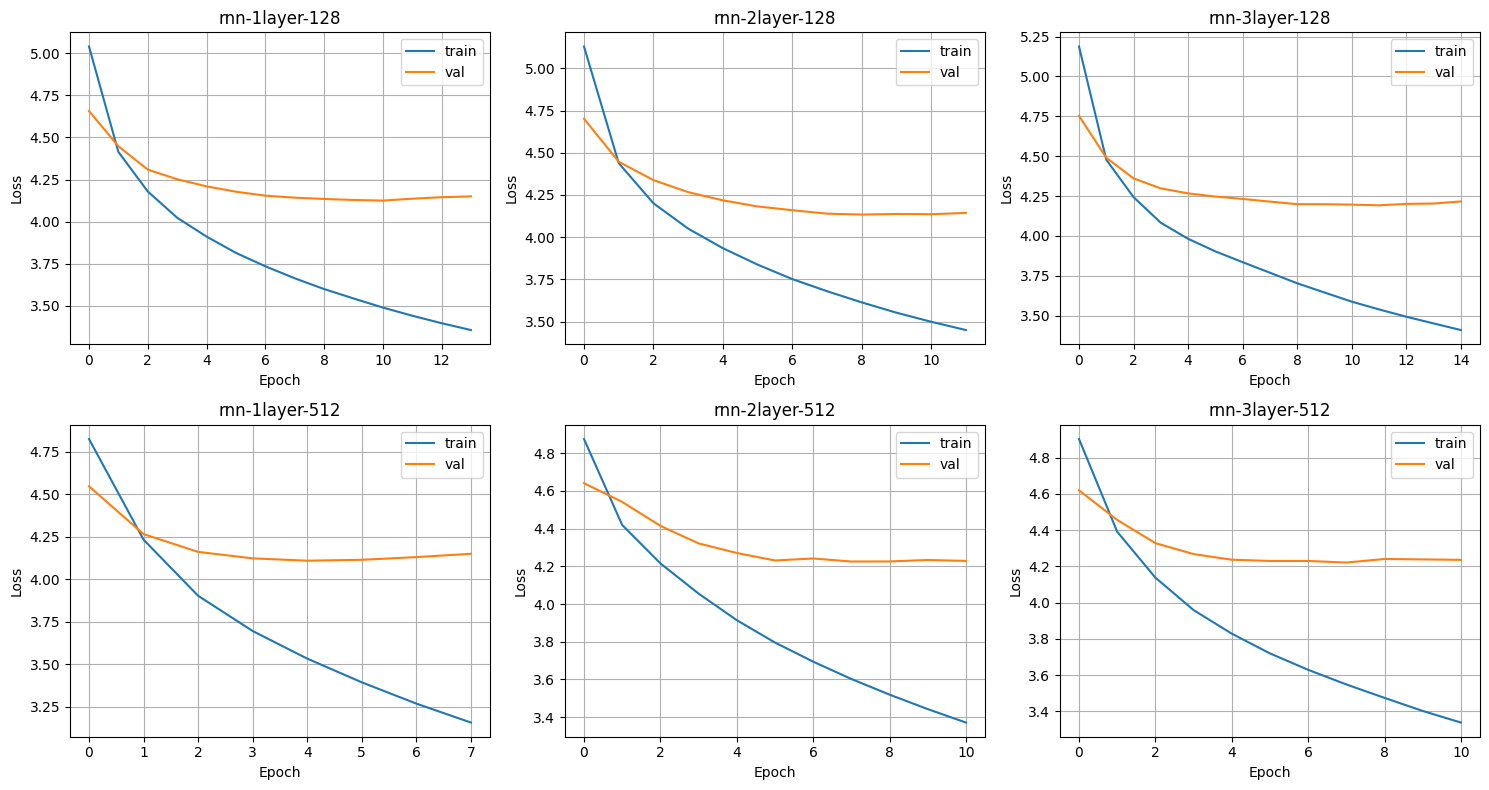

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, cfg in enumerate(VARIATIONS):
    name = cfg["name"]
    h    = all_histories[name]["history"]
    ax   = axes[i]
    ax.plot(h["loss"],     label="train")
    ax.plot(h["val_loss"], label="val")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, "training_curves_rnn.png"), dpi=120)
plt.show()

## Ringkasan hasil

In [9]:
print(f"{'Nama':<22} {'Layer':>6} {'Units':>6} {'Best val_loss':>14} {'Waktu (s)':>10}")
print("-" * 65)
for cfg in VARIATIONS:
    name = cfg["name"]
    h    = all_histories[name]
    best = min(h["history"]["val_loss"])
    t    = h["train_time_sec"]
    print(f"{name:<22} {cfg['num_rnn_layers']:>6} {cfg['rnn_units']:>6} {best:>14.4f} {t:>10.0f}")

Nama                    Layer  Units  Best val_loss  Waktu (s)
-----------------------------------------------------------------
rnn-1layer-128              1    128         4.1247        770
rnn-2layer-128              2    128         4.1342        689
rnn-3layer-128              3    128         4.1917        934
rnn-1layer-512              1    512         4.1082       1259
rnn-2layer-512              2    512         4.2254       2078
rnn-3layer-512              3    512         4.2214       2389
